<a href="https://colab.research.google.com/github/yrainjiang/Eye-Detection-AI/blob/main/Eye_Direction_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/eye_dataset')
os.listdir('/content/eye_dataset')

Saving archive (1).zip to archive (1).zip


['Eye dataset']

close_look -> 3828
forward_look -> 3457
left_look -> 3498
right_look -> 3577


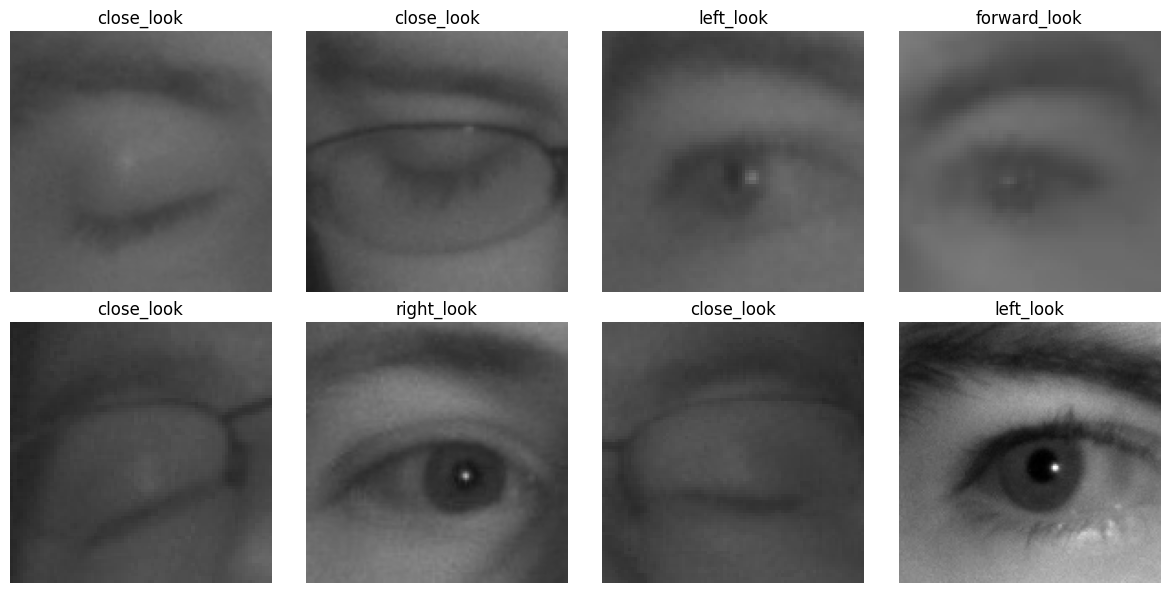

In [9]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt
BASE = "/content/eye_dataset/Eye dataset"

#builds a list and adds stuff
classes = [d for d in os.listdir(BASE) if os.path.isdir(os.path.join(BASE, d))]

for c in sorted(classes):
    print(c, "->", len(os.listdir(os.path.join(BASE, c))))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.ravel():
    cls = random.choice(classes)
    fp  = os.path.join(BASE, cls, random.choice(os.listdir(os.path.join(BASE, cls))))
    ax.imshow(Image.open(fp).convert('RGB'))
    ax.set_title(cls); ax.axis('off')
plt.tight_layout(); plt.show()

Found 11490 images belonging to 4 classes.
Found 2870 images belonging to 4 classes.
Classes: ['close_look', 'forward_look', 'left_look', 'right_look']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - accuracy: 0.8203 - loss: 0.4625 - val_accuracy: 0.8885 - val_loss: 0.2941
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 75s 208ms/step - accuracy: 0.9346 - loss: 0.2010 - val_accuracy: 0.9164 - val_loss: 0.2371
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 202ms/step - accuracy: 0.9527 - loss: 0.1458 - val_accuracy: 0.9258 - val_loss: 0.2814
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 202ms/step - accuracy: 0.9626 - loss: 0.1200 - val_accuracy: 0.9547 - val_loss: 0.1507
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 203ms/step - accuracy: 0.9691 - loss: 0.1020 - val_accuracy: 0.9519 - val_loss: 0.2119
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.9762 - loss: 0.0782 - val_accuracy: 0.9516 - val_loss: 0.2407
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.9781 - loss: 0.0697 - val_accuracy: 0.9575 - val_loss: 0.1561
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.9792 - loss: 0

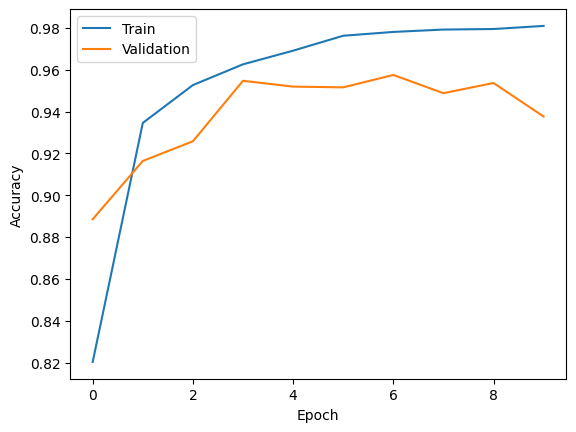

✅ Model saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

BASE  = "/content/eye_dataset/Eye dataset"
IMG   = (128, 128)
BATCH = 32
#Prepare data
gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    rotation_range=10,
    brightness_range=[0.9, 1.1],
    zoom_range=[0.9, 1.1]
)

train = gen.flow_from_directory(BASE, target_size=IMG, batch_size=BATCH, class_mode="categorical", subset="training",  shuffle=True)
val = gen.flow_from_directory(BASE, target_size=IMG, batch_size=BATCH, class_mode="categorical", subset="validation", shuffle=False)

labels = list(train.class_indices.keys())
print("Classes:", labels)

#Build model
model = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', input_shape=IMG+(3,)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64,  (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

#Train
history = model.fit(train, validation_data=val, epochs=10)

model.save('/content/eye_cnn_model.h5')